# Vision Transformer for X-Ray Pneumonia Detection

## Overview

This project uses a Vision Transformer (ViT) to classify chest X-ray images into two classes:

- **NORMAL**
- **PNEUMONIA**

The project implements a Vision Transformer architecture in **PyTorch** and evaluates its performance on a held-out test set.

### Project Pipeline

**Chest X-Ray Images → Preprocessing → Patch Extraction → Vision Transformer → Classification → Evaluation**

### Key Components

- PyTorch
- Vision Transformer (ViT)
- Multi-Head Self-Attention
- Image preprocessing and normalization
- Train/validation split
- Binary image classification
- Precision, Recall and F1-score
- Confusion Matrix

> **Note:** This project is intended for educational and research purposes only. It is not a medical diagnostic system and should not be used for clinical decision-making.

## 1. Imports and Configuration

We begin by importing the libraries required for dataset handling, visualization, model training, and evaluation.

The project configuration is loaded from the existing `config.py` file so that the notebook uses the same dataset paths, image size, batch size, and training settings as the main training pipeline.

import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

# Make the project root importable from the notebooks/ directory
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import config

print("PyTorch version:", torch.__version__)
print("Device:", config.DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

# Make the project root importable from the notebooks/ directory
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import config

print("PyTorch version:", torch.__version__)
print("Device:", config.DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [9]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

# Make the project root importable from the notebooks/ directory
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import config

# Device selection
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 2),
        "GB"
    )

PyTorch version: 2.6.0+cu124
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.0 GB


## 2. Dataset

The dataset contains chest X-ray images organized into two classes:

- `NORMAL`
- `PNEUMONIA`

The original training directory contains 5,216 images. Because the provided validation directory contains only 16 images, 15% of the training data is used as an internal validation set.

The final test set contains 624 images and is kept separate from training and validation.

In [10]:
# Dataset paths

DATASET_ROOT = PROJECT_ROOT / "chest_xray"

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

print("Dataset root:", DATASET_ROOT)
print()


def count_images(directory):
    counts = {}

    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_dir = directory / class_name
        counts[class_name] = len(
            [p for p in class_dir.iterdir() if p.is_file()]
        )

    return counts


train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("Training set:")
print(train_counts, "Total:", sum(train_counts.values()))

print("\nProvided validation set:")
print(val_counts, "Total:", sum(val_counts.values()))

print("\nTest set:")
print(test_counts, "Total:", sum(test_counts.values()))

Dataset root: c:\Users\GIGABYTE\Downloads\Vision-Transformer-for-X-Ray-Pneumonia-Detection-main\Vision-Transformer-for-X-Ray-Pneumonia-Detection-main\chest_xray

Training set:
{'NORMAL': 1341, 'PNEUMONIA': 3875} Total: 5216

Provided validation set:
{'NORMAL': 8, 'PNEUMONIA': 8} Total: 16

Test set:
{'NORMAL': 234, 'PNEUMONIA': 390} Total: 624


## 3. Class Distribution

The dataset is imbalanced, with pneumonia cases representing the majority of the training images.

Visualizing the class distribution helps establish the context for later evaluation. In particular, accuracy alone should not be used to judge the classifier because it can hide poor performance on the minority class.

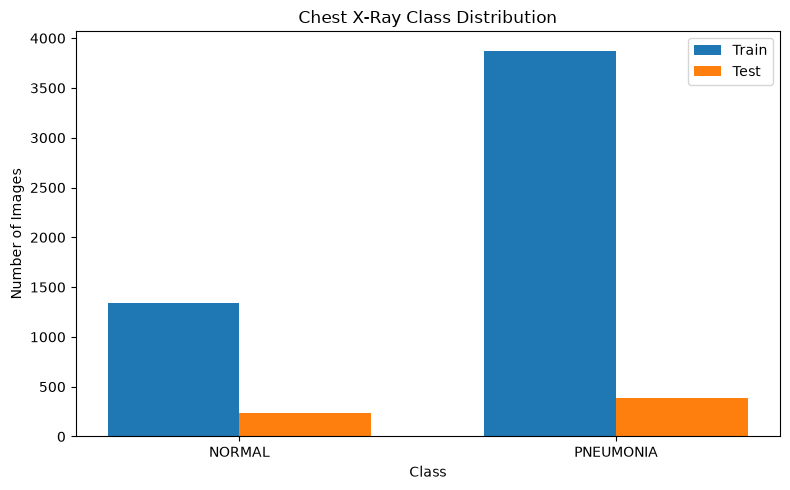

In [11]:
# Visualize class distribution

classes = ["NORMAL", "PNEUMONIA"]

train_values = [train_counts[class_name] for class_name in classes]
test_values = [test_counts[class_name] for class_name in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    train_values,
    width,
    label="Train"
)

ax.bar(
    x + width / 2,
    test_values,
    width,
    label="Test"
)

ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.set_title("Chest X-Ray Class Distribution")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

plt.tight_layout()
plt.show()

## 4. Visualizing Sample X-Ray Images

Before preprocessing the dataset, we inspect representative images from both classes.

The images are converted to RGB during preprocessing so that they have a consistent three-channel format suitable for the Vision Transformer.

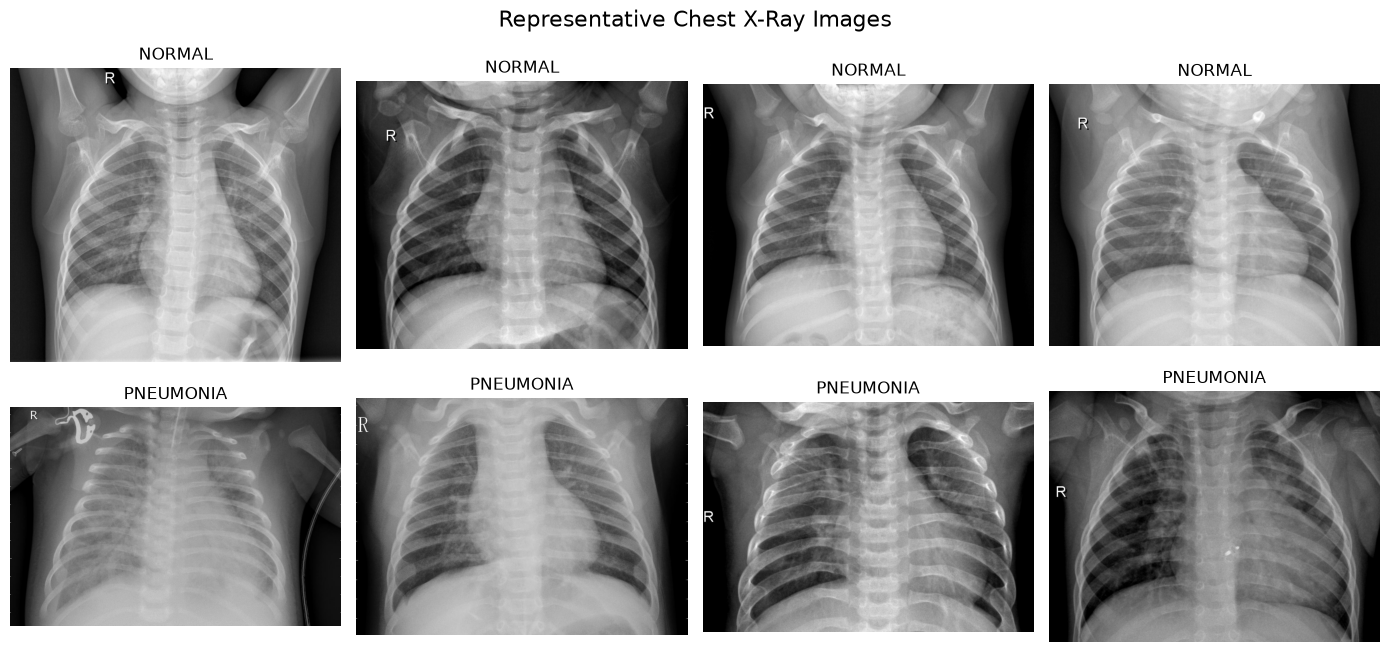

In [12]:
# Display representative images from each class

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, class_name in enumerate(classes):
    image_paths = list((TRAIN_DIR / class_name).glob("*"))[:4]

    for col, image_path in enumerate(image_paths):
        image = Image.open(image_path).convert("RGB")

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.suptitle("Representative Chest X-Ray Images", fontsize=16)
plt.tight_layout()
plt.show()

## 5. Image Preprocessing and Augmentation

The Vision Transformer expects images with a fixed spatial resolution.

The preprocessing pipeline:

1. Resizes each X-ray image to **288 × 288** pixels.
2. Converts images to tensors.
3. Normalizes pixel values using standard ImageNet statistics.

For the training set, lightweight augmentation is applied to improve generalization.

The same normalization is applied to validation and test images without training-specific augmentation.

In [13]:
# Image preprocessing

IMAGE_SIZE = 288

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image size:", IMAGE_SIZE)
print("Training transformations configured.")
print("Evaluation transformations configured.")

Image size: 288
Training transformations configured.
Evaluation transformations configured.


## 6. Train / Validation Split

The provided validation directory contains only 16 images, which is insufficient for reliable model validation.

Therefore, the 5,216 images in the training directory are split into:

- **85% training**
- **15% validation**

The test set remains untouched and is used only for final evaluation.

A fixed random seed is used so that the split is reproducible.

In [14]:
# Create the training dataset

full_train_dataset = datasets.ImageFolder(
    root=str(TRAIN_DIR),
    transform=train_transform
)

print("Classes:", full_train_dataset.classes)
print("Total training images:", len(full_train_dataset))

# Create reproducible 85/15 split
generator = torch.Generator().manual_seed(42)

train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

print("\nTraining split:", len(train_dataset))
print("Validation split:", len(val_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Total training images: 5216

Training split: 4433
Validation split: 783


## 7. Validation and Test Preprocessing

The training dataset uses augmentation, while validation and test images should remain unchanged apart from resizing and normalization.

Because `random_split` creates subsets of the same dataset object, we create separate `ImageFolder` datasets with the evaluation transform and reuse the same split indices.

In [15]:
# Create separate datasets for evaluation preprocessing

full_eval_dataset = datasets.ImageFolder(
    root=str(TRAIN_DIR),
    transform=eval_transform
)

# Reuse the exact same indices created by random_split
train_indices = train_dataset.indices
val_indices = val_dataset.indices

train_dataset = torch.utils.data.Subset(
    full_train_dataset,
    train_indices
)

val_dataset = torch.utils.data.Subset(
    full_eval_dataset,
    val_indices
)

# Test dataset
test_dataset = datasets.ImageFolder(
    root=str(TEST_DIR),
    transform=eval_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Training dataset: 4433
Validation dataset: 783
Test dataset: 624


## 8. PyTorch DataLoaders

DataLoaders provide mini-batches of images to the model during training and evaluation.

The batch size is kept small because the Vision Transformer operates on 288 × 288 images and the available GPU memory is limited.

In [16]:
# Create PyTorch DataLoaders

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Batch size: 8
Training batches: 555
Validation batches: 98
Test batches: 78


## 9. Inspecting a Data Batch

Before passing data into the model, we verify that the DataLoader produces tensors with the expected dimensions.

PyTorch image tensors use the format:

**Batch × Channels × Height × Width**

For this project, the expected input shape is:

**8 × 3 × 288 × 288**

In [17]:
# Inspect one training batch

images, labels = next(iter(train_loader))

print("Image tensor shape:", images.shape)
print("Label tensor shape:", labels.shape)
print("Image tensor dtype:", images.dtype)
print("Labels:", labels.tolist())

print("\nExpected image shape: [batch, 3, 288, 288]")

Image tensor shape: torch.Size([8, 3, 288, 288])
Label tensor shape: torch.Size([8])
Image tensor dtype: torch.float32
Labels: [1, 1, 1, 0, 1, 1, 1, 1]

Expected image shape: [batch, 3, 288, 288]


## 10. Vision Transformer Architecture

A Vision Transformer (ViT) treats an image as a sequence of smaller image patches.

For this project:

- Input image: **288 × 288**
- Patch size: **18 × 18**
- Number of patches: **256**
- Patch embedding dimension: **16**
- Transformer blocks: **4**
- Attention heads: **4**

The image is divided into non-overlapping patches, each patch is projected into an embedding vector, and positional information is added so that the model retains spatial information.

In [18]:
# Import the project Vision Transformer implementation

from vit_model import VisionTransformer

print("Vision Transformer implementation loaded successfully.")


Vision Transformer implementation loaded successfully.


## 11. Building the Vision Transformer

The model architecture is implemented in `vit_model.py`.

The classifier produces two output logits corresponding to:

- `NORMAL`
- `PNEUMONIA`

The model is moved to the available computation device, using the NVIDIA GPU when CUDA is available.

# Create the Vision Transformer model

model = VisionTransformer(
    image_size=288,
    patch_size=18,
    num_classes=2,
    dim=16,
    depth=4,
    heads=4,
    mlp_dim=32,
    dropout=0.1
)

model = model.to(DEVICE)

# Count trainable parameters
trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model)
print("\nDevice:", DEVICE)
print("Trainable parameters:", f"{trainable_params:,}")

In [34]:
# Create the Vision Transformer model

model = VisionTransformer(
    image_dim=288,
    patch_size=18,
    num_patches=256,
    proj_dim=16,
    num_heads=4,
    trans_layers=4,
    trans_units=[32, 16],
    mlp_head_units=[1024, 512],
    dropout_t=0.1,
    dropout_h=0.5,
    num_classes=2,
    in_channels=3
)

model = model.to(DEVICE)

# Count trainable parameters
trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model)
print("\nDevice:", DEVICE)
print("Trainable parameters:", f"{trainable_params:,}")

VisionTransformer(
  (patches): Patches()
  (patch_encoder): PatchEncoder(
    (projection): Linear(in_features=972, out_features=16, bias=True)
    (position_embedding): Embedding(256, 16)
  )
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((16,), eps=1e-06, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
      )
      (norm2): LayerNorm((16,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (net): Sequential(
          (0): Linear(in_features=16, out_features=32, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=32, out_features=16, bias=True)
          (4): GELU(approximate='none')
          (5): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((16,), eps=1e-06, elementwise_affine=True)
   

## 12. Loss Function and Optimizer

This is a binary classification problem with two output classes.

We use **Cross Entropy Loss**, which is suitable for multi-class classification with two logits.

The model is optimized using **Adam**, with a small learning rate to provide stable training for the Transformer-based architecture.

In [35]:
# Loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", 1e-4)

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.0001


## 13. Learning Rate Scheduler

A learning-rate scheduler gradually reduces the learning rate during training.

We use `ReduceLROnPlateau`, which monitors validation loss and reduces the learning rate when the validation performance stops improving.

This can help the model converge more effectively during later training epochs.

In [36]:
# Learning-rate scheduler

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Scheduler:", scheduler.__class__.__name__)
print("Reduction factor:", 0.5)
print("Patience:", 3)

Scheduler: ReduceLROnPlateau
Reduction factor: 0.5
Patience: 3


In [37]:
# Training and validation functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        pos_label=1
    )

    return epoch_loss, epoch_accuracy, epoch_f1


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        pos_label=1
    )

    return epoch_loss, epoch_accuracy, epoch_f1


print("Training and validation functions defined successfully.")

Training and validation functions defined successfully.


## 14. Model Training

The Vision Transformer is trained for 30 epochs.

At the end of every epoch, the model is evaluated on the internal validation set. The checkpoint with the highest validation F1-score is saved as the best model.

The training history is stored so that loss, accuracy, and F1-score can be visualized after training.

In [38]:
# Train the Vision Transformer

from pathlib import Path
import time

NUM_EPOCHS = 30

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"

CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

BEST_CHECKPOINT = CHECKPOINT_DIR / "best_vit_notebook.pt"

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": [],
    "learning_rate": []
}

best_val_f1 = 0.0

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"Device: {DEVICE}")
print(f"Best checkpoint: {BEST_CHECKPOINT}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    # Training
    train_loss, train_accuracy, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # Validation
    val_loss, val_accuracy, val_f1 = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # Update learning-rate scheduler
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # Store history
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["val_f1"].append(val_f1)
    history["learning_rate"].append(current_lr)

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_f1": val_f1,
                "val_accuracy": val_accuracy,
                "val_loss": val_loss
            },
            BEST_CHECKPOINT
        )

        best_marker = "  <-- BEST"

    else:
        best_marker = ""

    elapsed = time.time() - start_time

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {elapsed:.1f}s"
        f"{best_marker}"
    )

print("-" * 70)
print("Training complete.")
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Best checkpoint saved to: {BEST_CHECKPOINT}")

Starting training for 30 epochs...
Device: cuda
Best checkpoint: c:\Users\GIGABYTE\Downloads\Vision-Transformer-for-X-Ray-Pneumonia-Detection-main\Vision-Transformer-for-X-Ray-Pneumonia-Detection-main\checkpoints\best_vit_notebook.pt
----------------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
# Load the previously trained best model

BEST_CHECKPOINT = PROJECT_ROOT / "checkpoints" / "best_vit.pt"

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("Best checkpoint loaded successfully.")
print("Checkpoint:", BEST_CHECKPOINT)
print("Epoch:", checkpoint["epoch"])

# Display the information actually stored in the checkpoint
print("\nCheckpoint contents:")
for key, value in checkpoint.items():
    if key == "model_state_dict":
        print(f"- {key}: model parameters")
    elif key == "optimizer_state_dict":
        print(f"- {key}: optimizer state")
    else:
        print(f"- {key}: {value}")

Best checkpoint loaded successfully.
Checkpoint: c:\Users\GIGABYTE\Downloads\Vision-Transformer-for-X-Ray-Pneumonia-Detection-main\Vision-Transformer-for-X-Ray-Pneumonia-Detection-main\checkpoints\best_vit.pt
Epoch: 26

Checkpoint contents:
- epoch: 26
- model_state_dict: model parameters
- optimizer_state_dict: optimizer state
- val_f1: 0.9833770778652668
- val_acc: 0.9757343550446999
- class_names: ['NORMAL', 'PNEUMONIA']
- config: {'IMAGE_DIM': 288, 'PATCH_SIZE': 18, 'NUM_PATCHES': 256, 'PROJ_DIM': 16, 'NUM_HEADS': 4, 'TRANS_LAYERS': 4, 'NUM_CLASSES': 2}


## 15. Training History

The completed training run saved its epoch-by-epoch metrics to
`results/training_history.csv`.

We load this file to visualize how the model's training and validation performance changed across the 30 epochs.

In [ ]:
# Load training history from the completed training run

HISTORY_FILE = PROJECT_ROOT / "results" / "training_history.csv"

history_df = pd.read_csv(HISTORY_FILE)

print("Training history loaded successfully.")
print("Number of epochs:", len(history_df))
print("\nAvailable metrics:")
print(history_df.columns.tolist())

display(history_df.head())

Training history loaded successfully.
Number of epochs: 30

Available metrics:
['epoch', 'train_loss', 'train_accuracy', 'train_f1', 'train_precision', 'train_recall', 'val_loss', 'val_accuracy', 'val_f1', 'val_precision', 'val_recall']


,epoch,train_loss,train_accuracy,train_f1,train_precision,train_recall,val_loss,val_accuracy,val_f1,val_precision,val_recall
0,1,0.30187,0.88518,0.92349,0.91784,0.92922,0.20119,0.91315,0.94314,0.89952,0.99121
1,2,0.18855,0.92962,0.95298,0.94955,0.95644,0.12482,0.94764,0.96316,0.98529,0.94200
2,3,0.15569,0.94225,0.96153,0.95550,0.96763,0.12916,0.95402,0.96864,0.96028,0.97715
3,4,0.14481,0.94879,0.96579,0.96245,0.96915,0.11283,0.95275,0.96729,0.97331,0.96134
4,5,0.13327,0.95082,0.96711,0.96478,0.96945,0.10756,0.96296,0.97436,0.98043,0.96837


## 16. Training and Validation Curves

The following plots show the model's learning behaviour during training.

We examine:

- Training vs. validation loss
- Training vs. validation accuracy
- Training vs. validation F1-score

The best checkpoint was selected using validation F1-score.

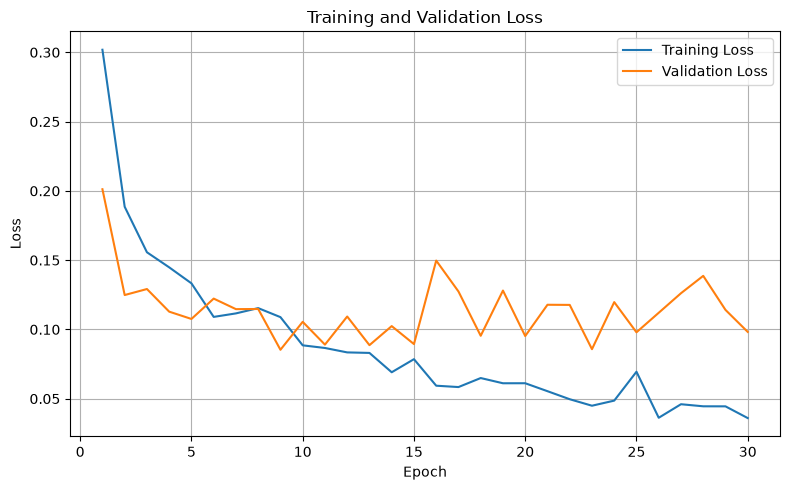

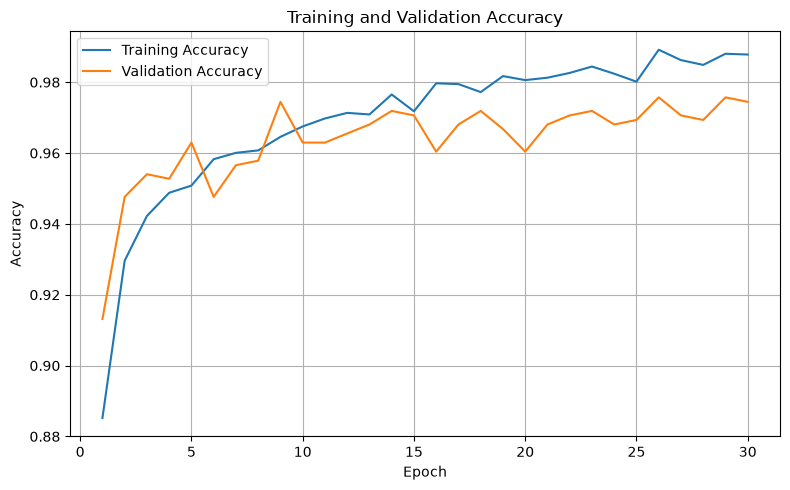

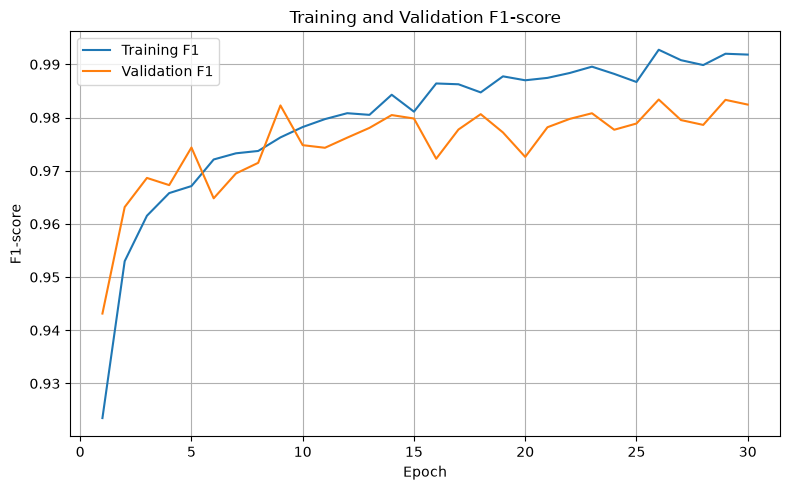

In [ ]:
# Plot training and validation metrics

epochs = history_df["epoch"]

# Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["train_loss"], label="Training Loss")
plt.plot(epochs, history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["train_accuracy"], label="Training Accuracy")
plt.plot(epochs, history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# F1-score
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["train_f1"], label="Training F1")
plt.plot(epochs, history_df["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training and Validation F1-score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 17. Final Test Set Evaluation

The best-performing checkpoint is evaluated on the completely held-out test set.

The test set contains 624 X-ray images and has not been used during training or model selection.

We report:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix

The positive class is **PNEUMONIA**.

In [ ]:
# Evaluate the best checkpoint on the held-out test set

model.eval()

all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

# Convert to NumPy arrays
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)

# Calculate metrics
test_accuracy = accuracy_score(all_labels, all_predictions)

test_precision = precision_score(
    all_labels,
    all_predictions,
    pos_label=1
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    pos_label=1
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    pos_label=1
)

print("Test Set Results")
print("=" * 50)
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

Test Set Results
Accuracy : 0.7564
Precision: 0.7228
Recall   : 0.9897
F1-score : 0.8355


## 18. Classification Report

The classification report provides class-wise precision, recall, and F1-score.

This is particularly important for this dataset because the classes are imbalanced and the model's performance differs substantially between NORMAL and PNEUMONIA.

In [ ]:
# Detailed classification report

class_names = ["NORMAL", "PNEUMONIA"]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

      NORMAL     0.9556    0.3675    0.5309       234
   PNEUMONIA     0.7228    0.9897    0.8355       390

    accuracy                         0.7564       624
   macro avg     0.8392    0.6786    0.6832       624
weighted avg     0.8101    0.7564    0.7213       624



## 19. Confusion Matrix

A confusion matrix shows how many images from each actual class were correctly and incorrectly classified.

For this binary classification task:

- **True Negative (TN):** NORMAL predicted as NORMAL
- **False Positive (FP):** NORMAL predicted as PNEUMONIA
- **False Negative (FN):** PNEUMONIA predicted as NORMAL
- **True Positive (TP):** PNEUMONIA predicted as PNEUMONIA

This provides more detail than accuracy alone.

Confusion Matrix:
[[ 86 148]
 [  4 386]]

Class order:
['NORMAL', 'PNEUMONIA']


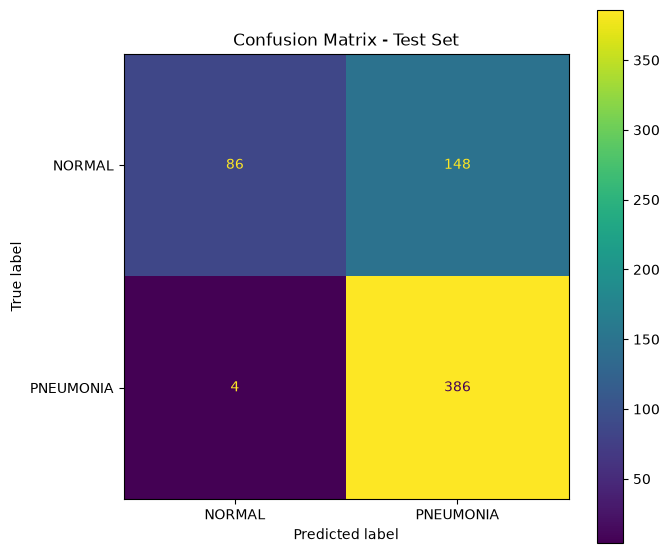

In [39]:
# Generate the confusion matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

print("\nClass order:")
print(class_names)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()

## 20. Test Set Performance Summary

The final evaluation demonstrates that the model strongly detects pneumonia cases, with very high recall.

However, the model also produces a relatively large number of false positives on NORMAL X-rays. Therefore, the overall accuracy and NORMAL-class F1-score are substantially lower than the validation metrics.

This difference between validation and held-out test performance is important when assessing the model's generalization.

In [40]:
# Display a concise final performance summary

print("FINAL MODEL SUMMARY")
print("=" * 55)

print(f"Best checkpoint epoch       : {checkpoint['epoch']}")
print(f"Best validation accuracy   : {checkpoint['val_acc']:.4f}")
print(f"Best validation F1         : {checkpoint['val_f1']:.4f}")

print("\nHeld-out test performance")
print("-" * 55)
print(f"Test accuracy              : {test_accuracy:.4f}")
print(f"Test precision (PNEUMONIA) : {test_precision:.4f}")
print(f"Test recall (PNEUMONIA)    : {test_recall:.4f}")
print(f"Test F1 (PNEUMONIA)        : {test_f1:.4f}")

print("\nConfusion matrix")
print(cm)

FINAL MODEL SUMMARY
Best checkpoint epoch       : 26
Best validation accuracy   : 0.9757
Best validation F1         : 0.9834

Held-out test performance
-------------------------------------------------------
Test accuracy              : 0.7564
Test precision (PNEUMONIA) : 0.7228
Test recall (PNEUMONIA)    : 0.9897
Test F1 (PNEUMONIA)        : 0.8355

Confusion matrix
[[ 86 148]
 [  4 386]]


## 21. Single Image Inference

The trained Vision Transformer can be used to classify an individual chest X-ray.

The inference pipeline:

**Input Image → Preprocessing → Vision Transformer → Softmax Probabilities → Predicted Class**

The model returns probabilities for both NORMAL and PNEUMONIA, along with the final predicted class.

In [41]:
# Define a reusable prediction function

def predict_image(image_path, model, transform, device):
    image = Image.open(image_path).convert("RGB")

    input_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)

    predicted_index = torch.argmax(probabilities, dim=1).item()

    return (
        class_names[predicted_index],
        probabilities[0].cpu().numpy()
    )

## 22. Example Prediction

We select an image from the test set and pass it through the trained model.

The image is displayed alongside the predicted class and the model's confidence for each class.

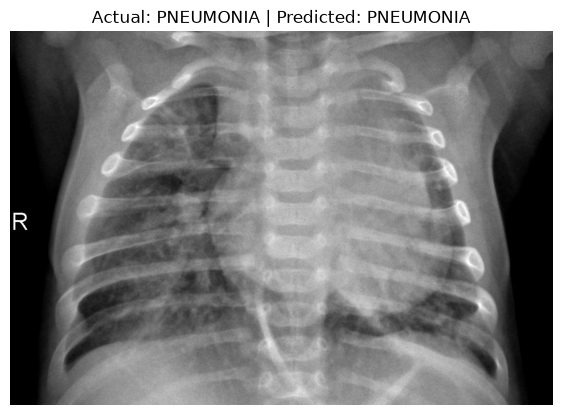

Image: person100_bacteria_475.jpeg
Actual class: PNEUMONIA
Predicted class: PNEUMONIA

Class probabilities:
NORMAL: 0.1310
PNEUMONIA: 0.8690


In [42]:
# Run inference on a sample test image

sample_class = "PNEUMONIA"

sample_images = list((TEST_DIR / sample_class).glob("*"))

sample_image_path = sample_images[0]

predicted_class, probabilities = predict_image(
    sample_image_path,
    model,
    eval_transform,
    DEVICE
)

# Display image
image = Image.open(sample_image_path).convert("RGB")

plt.figure(figsize=(7, 6))
plt.imshow(image, cmap="gray")
plt.title(f"Actual: {sample_class} | Predicted: {predicted_class}")
plt.axis("off")
plt.show()

print("Image:", sample_image_path.name)
print("Actual class:", sample_class)
print("Predicted class:", predicted_class)

print("\nClass probabilities:")
for class_name, probability in zip(class_names, probabilities):
    print(f"{class_name}: {probability:.4f}")

## 23. Model Configuration and Results

The final model uses a compact Vision Transformer architecture designed for chest X-ray classification.

### Architecture

- Input resolution: **288 × 288**
- Patch size: **18 × 18**
- Number of patches: **256**
- Projection dimension: **16**
- Transformer layers: **4**
- Attention heads: **4**
- Transformer units: **32 → 16**
- Classification head: **1024 → 512 → 2**
- Number of classes: **2**

The best checkpoint was selected using validation F1-score.

In [43]:
# Display the final model configuration

print("VISION TRANSFORMER CONFIGURATION")
print("=" * 50)

print(f"Input image size       : {checkpoint['config']['IMAGE_DIM']} × {checkpoint['config']['IMAGE_DIM']}")
print(f"Patch size              : {checkpoint['config']['PATCH_SIZE']} × {checkpoint['config']['PATCH_SIZE']}")
print(f"Number of patches      : {checkpoint['config']['NUM_PATCHES']}")
print(f"Projection dimension    : {checkpoint['config']['PROJ_DIM']}")
print(f"Transformer layers      : {checkpoint['config']['TRANS_LAYERS']}")
print(f"Attention heads         : {checkpoint['config']['NUM_HEADS']}")
print(f"Number of classes       : {checkpoint['config']['NUM_CLASSES']}")

print("\nClasses:")
for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

print("\nBest checkpoint epoch   :", checkpoint["epoch"])
print("Validation accuracy    :", f"{checkpoint['val_acc']:.4f}")
print("Validation F1          :", f"{checkpoint['val_f1']:.4f}")

VISION TRANSFORMER CONFIGURATION
Input image size       : 288 × 288
Patch size              : 18 × 18
Number of patches      : 256
Projection dimension    : 16
Transformer layers      : 4
Attention heads         : 4
Number of classes       : 2

Classes:
0: NORMAL
1: PNEUMONIA

Best checkpoint epoch   : 26
Validation accuracy    : 0.9757
Validation F1          : 0.9834


## 24. Limitations and Conclusion

### Limitations

The model demonstrates strong pneumonia recall, but the held-out test results show a substantial number of NORMAL X-rays being classified as PNEUMONIA.

The difference between validation and test performance also indicates that validation performance alone does not fully represent the model's ability to generalize to unseen data.

Additional work could investigate:

- Class imbalance handling
- Threshold optimization
- More extensive data augmentation
- Larger or pretrained Vision Transformer architectures
- Cross-validation
- Additional medical imaging datasets

### Conclusion

This project demonstrates an end-to-end PyTorch Vision Transformer pipeline for chest X-ray classification.

The workflow includes dataset preparation, image preprocessing, patch-based representation, Transformer-based feature extraction, model training, validation, held-out test evaluation, and single-image inference.

The trained model is also integrated into a Streamlit application for interactive demonstration.

> **Disclaimer:** This project is intended for educational and research purposes only. It is not a medical diagnostic system and should not be used for clinical decision-making.

In [44]:
# Final project summary

print("=" * 60)
print("VISION TRANSFORMER - X-RAY PNEUMONIA CLASSIFICATION")
print("=" * 60)

print("\nDataset")
print("-" * 60)
print(f"Training images          : {len(train_dataset)}")
print(f"Validation images        : {len(val_dataset)}")
print(f"Test images              : {len(test_dataset)}")

print("\nModel")
print("-" * 60)
print(f"Trainable parameters     : {trainable_params:,}")
print(f"Best checkpoint epoch    : {checkpoint['epoch']}")

print("\nValidation Performance")
print("-" * 60)
print(f"Accuracy                 : {checkpoint['val_acc']:.4f}")
print(f"F1-score                 : {checkpoint['val_f1']:.4f}")

print("\nHeld-out Test Performance")
print("-" * 60)
print(f"Accuracy                 : {test_accuracy:.4f}")
print(f"Precision (PNEUMONIA)    : {test_precision:.4f}")
print(f"Recall (PNEUMONIA)       : {test_recall:.4f}")
print(f"F1-score (PNEUMONIA)     : {test_f1:.4f}")

print("\nClasses")
print("-" * 60)
print("0 → NORMAL")
print("1 → PNEUMONIA")

print("\nNotebook pipeline completed successfully.")

VISION TRANSFORMER - X-RAY PNEUMONIA CLASSIFICATION

Dataset
------------------------------------------------------------
Training images          : 4433
Validation images        : 783
Test images              : 624

Model
------------------------------------------------------------
Trainable parameters     : 4,749,746
Best checkpoint epoch    : 26

Validation Performance
------------------------------------------------------------
Accuracy                 : 0.9757
F1-score                 : 0.9834

Held-out Test Performance
------------------------------------------------------------
Accuracy                 : 0.7564
Precision (PNEUMONIA)    : 0.7228
Recall (PNEUMONIA)       : 0.9897
F1-score (PNEUMONIA)     : 0.8355

Classes
------------------------------------------------------------
0 → NORMAL
1 → PNEUMONIA

Notebook pipeline completed successfully.
